# HLA-B39 Simulation Analysis - Visualization & Analysis

This notebook performs analysis and visualization using preprocessed data.

**Prerequisites:** Run `1_preprocessing.py` first to generate CSV files.

---

In [2]:
import glob
from prody import *
import pandas as pd
import re
import numpy as np
import tqdm
import natsort
import seaborn as sns
import scipy.stats
import matplotlib.pyplot as plt
import py3Dmol
import networkx as nx

## 2.1 Load Preprocessed Data

Load all CSV files generated by the preprocessing script.

In [3]:
# Initialize common variables and load all preprocessed datasets
BASE_FOLDER = '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/'
frame_cols = list(map(str, np.arange(0, 239, 1)))

# Load all CSV files from preprocessing
print('Loading preprocessed datasets...')
df_intEn = pd.read_csv('intEnVdW_2025_07_10.csv')
df_cons_pairs = pd.read_csv('df_cons_pairs_saved_2025_07_10.csv')
df_sig_aff_pairs_b39 = pd.read_csv('df_sig_aff_pairs_b39_2025_07_10.csv')
df_sig_aff_pairs_loaded = pd.read_csv('df_sig_aff_pairs_loaded_2025_07_10.csv')
df_bc_equil = pd.read_csv('df_bc_equil_2025_07_10.csv')
df_bc_equil_cons_resids = pd.read_csv('df_bc_equil_cons_resids_2025_07_10.csv')
df_bc_sig_aff_resids = pd.read_csv('df_bc_sigaff_resids_2026_01_27.csv')

print('All datasets loaded successfully.')
print(f'  - df_intEn: {len(df_intEn)} rows')
print(f'  - df_cons_pairs: {len(df_cons_pairs)} rows')
print(f'  - df_sig_aff_pairs_b39: {len(df_sig_aff_pairs_b39)} rows')
print(f'  - df_sig_aff_pairs_loaded: {len(df_sig_aff_pairs_loaded)} rows')
print(f'  - df_bc_equil_cons_resids: {len(df_bc_equil_cons_resids)} rows')
print(f'  - df_bc_sig_aff_resids: {len(df_bc_sig_aff_resids)} rows')

Loading preprocessed datasets...


/tmp/ipykernel_3190227/3034445152.py:7: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_intEn = pd.read_csv('intEnVdW_2025_07_10.csv')
/tmp/ipykernel_3190227/3034445152.py:8: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cons_pairs = pd.read_csv('df_cons_pairs_saved_2025_07_10.csv')


All datasets loaded successfully.
  - df_intEn: 149957 rows
  - df_cons_pairs: 63252 rows
  - df_sig_aff_pairs_b39: 22 rows
  - df_sig_aff_pairs_loaded: 951 rows
  - df_bc_equil_cons_resids: 3910683 rows
  - df_bc_sig_aff_resids: 274 rows


## 2.2 Summary Statistics

Overview of interaction changes by allele and peptide across systems.

In [4]:
# Get unique alleles and peptides from the data
unique_alleles = df_sig_aff_pairs_loaded['allele'].unique()
unique_peptides = df_sig_aff_pairs_loaded['peptide'].unique()

print("=== INTERACTION CHANGES BY ALLELE AND PEPTIDE ===\n")

# Create a mapping of peptides to their full names (you can expand this)
peptide_names = {
    'ALL': 'peptide ALL',
    'A': 'peptide A',  # Update with actual peptide name if known
    'AL': 'peptide AL',  # Update with actual peptide name if known
    # Add more mappings as needed
}

for allele in sorted(unique_alleles):
    print(f"--- {allele} ---")
    allele_data = df_sig_aff_pairs_loaded[df_sig_aff_pairs_loaded['allele'] == allele]
    
    for peptide in sorted(allele_data['peptide'].unique()):
        peptide_data = allele_data[allele_data['peptide'] == peptide]
        
        # Get full peptide name if available
        full_peptide_name = peptide_names.get(peptide, peptide)
        
        repulsive_count = len(peptide_data[peptide_data['change_type'] == 'repulsive'])
        attractive_count = len(peptide_data[peptide_data['change_type'] == 'attractive'])
        
        print(f"  Peptide {peptide} ({full_peptide_name}):")
        print(f"    Repulsive interactions: {repulsive_count}")
        print(f"    Attractive interactions: {attractive_count}")
        print(f"    Total interactions: {repulsive_count + attractive_count}")
    
    print()

# Summary statistics
print("=== OVERALL SUMMARY ===")
total_repulsive = len(df_sig_aff_pairs_loaded[df_sig_aff_pairs_loaded['change_type'] == 'repulsive'])
total_attractive = len(df_sig_aff_pairs_loaded[df_sig_aff_pairs_loaded['change_type'] == 'attractive'])
total_interactions = len(df_sig_aff_pairs_loaded)

print(f"Total significantly affected pairs: {total_interactions}")
print(f"Total repulsive changes: {total_repulsive}")
print(f"Total attractive changes: {total_attractive}")

# Breakdown by allele
print(f"\nBreakdown by allele:")
allele_summary = df_sig_aff_pairs_loaded.groupby(['allele', 'change_type']).size().unstack(fill_value=0)
print(allele_summary)

# Breakdown by peptide
print(f"\nBreakdown by peptide:")
peptide_summary = df_sig_aff_pairs_loaded.groupby(['peptide', 'change_type']).size().unstack(fill_value=0)
print(peptide_summary)

=== INTERACTION CHANGES BY ALLELE AND PEPTIDE ===

--- B3801 ---
  Peptide A (peptide A):
    Repulsive interactions: 3
    Attractive interactions: 308
    Total interactions: 311
  Peptide AL (peptide AL):
    Repulsive interactions: 2
    Attractive interactions: 307
    Total interactions: 309
  Peptide ALL (peptide ALL):
    Repulsive interactions: 2
    Attractive interactions: 309
    Total interactions: 311

--- B3901 ---
  Peptide A (peptide A):
    Repulsive interactions: 2
    Attractive interactions: 2
    Total interactions: 4
  Peptide AL (peptide AL):
    Repulsive interactions: 2
    Attractive interactions: 3
    Total interactions: 5
  Peptide ALL (peptide ALL):
    Repulsive interactions: 2
    Attractive interactions: 2
    Total interactions: 4

--- B3906 ---
  Peptide A (peptide A):
    Repulsive interactions: 1
    Attractive interactions: 1
    Total interactions: 2
  Peptide AL (peptide AL):
    Repulsive interactions: 0
    Attractive interactions: 1
    Total

In [5]:
# Explore available data combinations
print("Available alleles:", sorted(df_sig_aff_pairs_loaded['allele'].unique()))
print("Available peptides:", sorted(df_sig_aff_pairs_loaded['peptide'].unique()))
print("\nData combinations (allele, peptide):")
combinations = df_sig_aff_pairs_loaded[['allele', 'peptide']].drop_duplicates().sort_values(['allele', 'peptide'])
for _, row in combinations.iterrows():
    count = len(df_sig_aff_pairs_loaded[(df_sig_aff_pairs_loaded['allele'] == row['allele']) & 
                                       (df_sig_aff_pairs_loaded['peptide'] == row['peptide'])])
    print(f"  {row['allele']} + {row['peptide']}: {count} pairs")

Available alleles: ['B3801', 'B3901', 'B3906']
Available peptides: ['A', 'AL', 'ALL']

Data combinations (allele, peptide):
  B3801 + A: 311 pairs
  B3801 + AL: 309 pairs
  B3801 + ALL: 311 pairs
  B3901 + A: 4 pairs
  B3901 + AL: 5 pairs
  B3901 + ALL: 4 pairs
  B3906 + A: 2 pairs
  B3906 + AL: 1 pairs
  B3906 + ALL: 4 pairs


## 2.3 3D Structure Visualization

Visualize significantly affected residue pairs in 3D (red = attractive, blue = repulsive).

In [ ]:
def vis_pairs(pdb_file, df_tovis, pair_color='red'):
    pdb_str = open(pdb_file, 'r').read()
    # Initialize viewer
    view = py3Dmol.view(width=800, height=600)

    # Add model from the PDB string
    view.addModel(pdb_str, 'pdb')

    # Apply cartoon representation for the entire protein
    view.setStyle({'cartoon': {}})

    for pair in df_tovis['pair'].unique():
        res1 = pair.split('-')[0]
        res2 = pair.split('-')[1]
        # Highlight residues 182-210 in chain A with Van der Waals (VDW) representation
        view.setStyle({'chain':res1[-1], 'resi':res1[:-1]}, {'sphere': {'radius': 1.0, 'color': pair_color}})
        view.setStyle({'chain':res2[-1], 'resi':res2[:-1]}, {'sphere': {'radius': 1.0, 'color': pair_color}})

    # Zoom to the selected residues
    view.zoomTo()

    # Show the viewer
    view.show()

In [ ]:
def generate_pymol_script(pdb_file, df_tovis, pair_color='red', output_file=None):
    """
    Generate a PyMOL script to visualize residue pairs.
    
    Parameters:
    - pdb_file: path to PDB structure file
    - df_tovis: DataFrame with 'pair' column containing pairs like "78M-95M"
    - pair_color: color for spheres ('red' or 'blue')
    - output_file: optional path to save the .pml script
    
    Returns:
    - PyMOL script as a string
    """
    lines = []
    
    # Load structure
    lines.append("# PyMOL visualization script")
    lines.append("# Generated from vis_pairs equivalent")
    lines.append("# Includes Goodsell-style matte rendering settings")
    lines.append("")
    lines.append(f"load {pdb_file}, structure")
    lines.append("")
    
    # Ambient occlusion and Goodsell-style matte rendering settings
    lines.append("# ===========================================")
    lines.append("# Publication-quality Goodsell-style settings")
    lines.append("# ===========================================")
    lines.append("")
    lines.append("# Background")
    lines.append("set bg_color, white")
    lines.append("")
    lines.append("# Ambient occlusion for soft shadows")
    lines.append("set ambient_occlusion_mode, 1")
    lines.append("set ambient_occlusion_scale, 25")
    lines.append("set ambient_occlusion_smooth, 10")
    lines.append("")
    lines.append("# Matte/flat shading (no specular highlights)")
    lines.append("set specular, 0")
    lines.append("set spec_reflect, 0")
    lines.append("set shininess, 0")
    lines.append("")
    lines.append("# Lighting for soft, diffuse look")
    lines.append("set ambient, 0.4")
    lines.append("set direct, 0.6")
    lines.append("set reflect, 0.0")
    lines.append("")
    lines.append("# Ray tracing settings (Goodsell-style)")
    lines.append("set ray_trace_mode, 1")
    lines.append("set ray_trace_gain, 0")
    lines.append("set ray_trace_color, black")
    lines.append("set ray_shadow, 1")
    lines.append("")
    lines.append("# High quality rendering")
    lines.append("set antialias, 2")
    lines.append("set ray_trace_fog, 0")
    lines.append("set depth_cue, 0")
    lines.append("")
    
    # Set up visualization
    lines.append("# Set up cartoon representation")
    lines.append("hide all")
    lines.append("show cartoon, structure")
    lines.append("color gray80, structure")
    lines.append("set cartoon_fancy_helices, 1")
    lines.append("set cartoon_smooth_loops, 1")
    lines.append("")
    
    # Build selection for all residues in pairs
    if len(df_tovis) == 0:
        lines.append("# No pairs to visualize")
        lines.append("")
        lines.append("# To render: ray 2400, 2400")
        lines.append("# To save: png output.png, dpi=300")
        script = "\n".join(lines)
        if output_file:
            with open(output_file, 'w') as f:
                f.write(script)
        return script
    
    selection_parts = []
    for pair in df_tovis['pair'].unique():
        res1 = pair.split('-')[0]
        res2 = pair.split('-')[1]
        chain1 = res1[-1]
        resi1 = res1[:-1]
        chain2 = res2[-1]
        resi2 = res2[:-1]
        selection_parts.append(f"(chain {chain1} and resi {resi1})")
        selection_parts.append(f"(chain {chain2} and resi {resi2})")
    
    # Remove duplicates while preserving order
    seen = set()
    unique_selections = []
    for s in selection_parts:
        if s not in seen:
            seen.add(s)
            unique_selections.append(s)
    
    selection_str = " or ".join(unique_selections)
    
    lines.append("# Select and highlight residue pairs")
    lines.append(f"select pair_residues, {selection_str}")
    lines.append("")
    
    # Show spheres and color
    lines.append("# Show spheres and apply color")
    lines.append("show spheres, pair_residues")
    lines.append(f"color {pair_color}, pair_residues")
    lines.append("set sphere_scale, 1.0, pair_residues")
    lines.append("set sphere_mode, 0")
    lines.append("")
    
    # Zoom to highlighted residues
    lines.append("# Zoom to highlighted residues")
    lines.append("zoom pair_residues")
    lines.append("")
    lines.append("# Deselect to clean up view")
    lines.append("deselect")
    lines.append("")
    lines.append("# ===========================================")
    lines.append("# To render publication-quality image:")
    lines.append("# ray 2400, 2400")
    lines.append("# png output.png, dpi=300")
    lines.append("# ===========================================")
    
    script = "\n".join(lines)
    
    if output_file:
        with open(output_file, 'w') as f:
            f.write(script)
        print(f"PyMOL script saved to: {output_file}")
    
    return script

### B3801 Visualizations

In [ ]:
# Load your PDB structure as a string
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'ALL' and change_type == 'attractive'").copy(),
          'red')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'ALL' and change_type == 'attractive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'ALL' and change_type == 'attractive'").copy(),
    pair_color='red',
    output_file='B3801_ALL_attractive_pairs.pml'
)

In [ ]:
# Load your PDB structure as a string
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'ALL' and change_type == 'repulsive'").copy(),
          'blue')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'ALL' and change_type == 'repulsive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'ALL' and change_type == 'repulsive'").copy(),
    pair_color='blue',
    output_file='B3801_ALL_repulsive_pairs.pml'
)

In [ ]:
# Load your PDB structure as a string
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_AL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'AL' and change_type == 'attractive'").copy(),
          'red')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'AL' and change_type == 'attractive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'AL' and change_type == 'attractive'").copy(),
    pair_color='red',
    output_file='B3801_AL_attractive_pairs.pml'
)

In [ ]:
# Load your PDB structure as a string
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_AL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'AL' and change_type == 'repulsive'").copy(),
          'blue')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'AL' and change_type == 'repulsive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'AL' and change_type == 'repulsive'").copy(),
    pair_color='blue',
    output_file='B3801_AL_repulsive_pairs.pml'
)

In [ ]:
# Load your PDB structure as a string
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_AL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'A' and change_type == 'attractive'").copy(),
          'red')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'A' and change_type == 'attractive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'A' and change_type == 'attractive'").copy(),
    pair_color='red',
    output_file='B3801_A_attractive_pairs.pml'
)

In [ ]:
# Load your PDB structure as a string
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_AL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'A' and change_type == 'repulsive'").copy(),
          'blue')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'A' and change_type == 'repulsive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'A' and change_type == 'repulsive'").copy(),
    pair_color='blue',
    output_file='B3801_A_repulsive_pairs.pml'
)

### B3901 Visualizations

In [ ]:
# B3901 ALL - Attractive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3901_ALL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'ALL' and change_type == 'attractive'").copy(),
          'red')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'ALL' and change_type == 'attractive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'ALL' and change_type == 'attractive'").copy(),
    pair_color='red',
    output_file='B3901_ALL_attractive_pairs.pml'
)

In [ ]:
# B3901 ALL - Repulsive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3901_ALL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'ALL' and change_type == 'repulsive'").copy(),
          'blue')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'ALL' and change_type == 'repulsive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'ALL' and change_type == 'repulsive'").copy(),
    pair_color='blue',
    output_file='B3901_ALL_repulsive_pairs.pml'
)

In [ ]:
# B3901 AL - Attractive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3901_AL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'AL' and change_type == 'attractive'").copy(),
          'red')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'AL' and change_type == 'attractive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'AL' and change_type == 'attractive'").copy(),
    pair_color='red',
    output_file='B3901_AL_attractive_pairs.pml'
)

In [ ]:
# B3901 AL - Repulsive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3901_AL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'AL' and change_type == 'repulsive'").copy(),
          'blue')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'AL' and change_type == 'repulsive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'AL' and change_type == 'repulsive'").copy(),
    pair_color='blue',
    output_file='B3901_AL_repulsive_pairs.pml'
)

In [ ]:
# B3901 A - Attractive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3901_A_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'A' and change_type == 'attractive'").copy(),
          'red')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'A' and change_type == 'attractive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'A' and change_type == 'attractive'").copy(),
    pair_color='red',
    output_file='B3901_A_attractive_pairs.pml'
)

In [ ]:
# B3901 A - Repulsive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3901_A_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'A' and change_type == 'repulsive'").copy(),
          'blue')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'A' and change_type == 'repulsive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'A' and change_type == 'repulsive'").copy(),
    pair_color='blue',
    output_file='B3901_A_repulsive_pairs.pml'
)

### B3906 Visualizations

In [ ]:
# B3906 ALL - Attractive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3906_ALL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'ALL' and change_type == 'attractive'").copy(),
          'red')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'ALL' and change_type == 'attractive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'ALL' and change_type == 'attractive'").copy(),
    pair_color='red',
    output_file='B3906_ALL_attractive_pairs.pml'
)

In [ ]:
# B3906 ALL - Repulsive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3906_ALL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'ALL' and change_type == 'repulsive'").copy(),
          'blue')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'ALL' and change_type == 'repulsive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'ALL' and change_type == 'repulsive'").copy(),
    pair_color='blue',
    output_file='B3906_ALL_repulsive_pairs.pml'
)

In [ ]:
# B3906 AL - Attractive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3906_AL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'AL' and change_type == 'attractive'").copy(),
          'red')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'AL' and change_type == 'attractive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'AL' and change_type == 'attractive'").copy(),
    pair_color='red',
    output_file='B3906_AL_attractive_pairs.pml'
)

In [ ]:
# B3906 AL - Repulsive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3906_AL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'AL' and change_type == 'repulsive'").copy(),
          'blue')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'AL' and change_type == 'repulsive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'AL' and change_type == 'repulsive'").copy(),
    pair_color='blue',
    output_file='B3906_AL_repulsive_pairs.pml'
)

In [ ]:
# B3906 A - Attractive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3906_A_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'A' and change_type == 'attractive'").copy(),
          'red')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'A' and change_type == 'attractive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'A' and change_type == 'attractive'").copy(),
    pair_color='red',
    output_file='B3906_A_attractive_pairs.pml'
)

In [ ]:
# B3906 A - Repulsive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3906_A_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'A' and change_type == 'repulsive'").copy(),
          'blue')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'A' and change_type == 'repulsive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'A' and change_type == 'repulsive'").copy(),
    pair_color='blue',
    output_file='B3906_A_repulsive_pairs.pml'
)

## 2.4 Network Centrality

Analyze the relationship between evolutionary conservation scores and network centrality changes.

In [16]:
def plot_bc_ridgeplot_grid(df_bc_sig_aff, df_bc_equil, n_residues=5):
    """
    Create consolidated ridge plot showing BC distributions for top/bottom residues
    across all 3 alleles, with peptides consolidated per allele.
    
    Parameters:
    - df_bc_sig_aff: DataFrame with diff_bc columns (df_bc_sig_aff_resids)
    - df_bc_equil: DataFrame with BC values (df_bc_equil_cons_resids)
    - n_residues: Number of top/bottom residues to collect per comparison (default 5)
    
    Returns:
    - matplotlib Figure
    """
    from scipy import stats
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    
    alleles = ['B3801', 'B3901', 'B3906']
    peptides = ['A', 'AL', 'ALL']
    
    # Step 1: Collect merged set of top and bottom residues across ALL comparisons
    top_resids_all = set()
    bottom_resids_all = set()
    
    for allele in alleles:
        for peptide in peptides:
            sort_col = f'diff_bc_{allele}_{peptide}'
            if sort_col in df_bc_sig_aff.columns:
                df_sorted = df_bc_sig_aff.dropna(subset=[sort_col]).sort_values(sort_col, ascending=False)
                top_resids_all.update(df_sorted.head(n_residues)['Residue_id'].tolist())
                bottom_resids_all.update(df_sorted.tail(n_residues)['Residue_id'].tolist())
    
    # Convert to sorted lists
    top_resids_list = sorted(top_resids_all, key=lambda x: (x.split('_')[1] if '_' in x else x[-1], int(x.split('_')[0]) if '_' in x else int(x[:-1])))
    bottom_resids_list = sorted(bottom_resids_all, key=lambda x: (x.split('_')[1] if '_' in x else x[-1], int(x.split('_')[0]) if '_' in x else int(x[:-1])))
    
    # Combine: top residues first (red), then bottom (blue)
    all_resids = top_resids_list + bottom_resids_list
    n_top = len(top_resids_list)
    n_bottom = len(bottom_resids_list)
    
    print(f"Merged residue set: {n_top} top (increased BC) + {n_bottom} bottom (decreased BC) = {len(all_resids)} total")
    
    # Step 2: Determine global X-axis range from all data
    all_bc_values = []
    for allele in alleles:
        systems = [allele] + [f'{allele}_{pep}' for pep in peptides]
        df_subset = df_bc_equil[
            (df_bc_equil['system'].isin(systems)) & 
            (df_bc_equil['Residue_id'].isin(all_resids))
        ]['BC'].dropna()
        all_bc_values.extend(df_subset.tolist())
    
    if all_bc_values:
        x_min = np.percentile(all_bc_values, 1)
        x_max = np.percentile(all_bc_values, 99)
    else:
        x_min, x_max = 0, 0.1
    
    # Step 3: Create figure with 1 row x 3 columns (one per allele)
    fig, axes = plt.subplots(1, 3, figsize=(10, max(8, len(all_resids) * 0.5)))
    
    # Color shades for peptides (light to dark for A, AL, ALL)
    # Red shades for increased BC residues (top)
    red_shades = {
        'A': '#FFCCCC',    # light red
        'AL': '#FF6666',   # medium red
        'ALL': '#CC0000'   # dark red
    }
    red_edges = {
        'A': '#FF9999',
        'AL': '#FF3333', 
        'ALL': '#990000'
    }
    
    # Blue shades for decreased BC residues (bottom)
    blue_shades = {
        'A': '#CCE5FF',    # light blue
        'AL': '#6699FF',   # medium blue
        'ALL': '#0033CC'   # dark blue
    }
    blue_edges = {
        'A': '#99CCFF',
        'AL': '#3366FF',
        'ALL': '#002299'
    }
    
    for col_idx, allele in enumerate(alleles):
        ax = axes[col_idx]
        
        # Systems for this allele
        peptide_free_system = allele
        all_systems = [peptide_free_system] + [f'{allele}_{pep}' for pep in peptides]
        
        # Filter data
        df_plot = df_bc_equil[
            (df_bc_equil['system'].isin(all_systems)) & 
            (df_bc_equil['Residue_id'].isin(all_resids))
        ].copy()
        
        if len(df_plot) == 0:
            ax.text(0.5, 0.5, f'No data for {allele}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(allele, fontsize=14, fontweight='bold')
            continue
        
        # Create ridge plot
        y_offset = 0
        y_positions = []
        y_labels = []
        
        for idx, resid in enumerate(all_resids):
            # Determine if this is a top (red) or bottom (blue) residue
            is_top = idx < n_top
            if is_top:
                fill_colors = red_shades
                edge_colors = red_edges
                label_prefix = '\u2191'  # up arrow
            else:
                fill_colors = blue_shades
                edge_colors = blue_edges
                label_prefix = '\u2193'  # down arrow
            
            df_res = df_plot[df_plot['Residue_id'] == resid]
            x_range = np.linspace(x_min, x_max, 150)
            
            # Plot each peptide-bound system FIRST (so they stack underneath)
            # Plot in reverse order (ALL, AL, A) so darker is at back, lighter at front
            for pep in reversed(peptides):
                system = f'{allele}_{pep}'
                df_sys = df_res[df_res['system'] == system]['BC'].dropna()
                if len(df_sys) > 10:
                    try:
                        kde = stats.gaussian_kde(df_sys)
                        density = kde(x_range)
                        density = density / density.max() * 0.7 if density.max() > 0 else density
                        # Filled distribution with edge
                        ax.fill_between(x_range, y_offset, y_offset + density, 
                                       alpha=0.6, color=fill_colors[pep], 
                                       edgecolor=edge_colors[pep], linewidth=1.2)
                    except Exception:
                        pass
            
            # Plot peptide-free LAST (dashed line, no fill, on top)
            df_pf = df_res[df_res['system'] == peptide_free_system]['BC'].dropna()
            if len(df_pf) > 10:
                try:
                    kde = stats.gaussian_kde(df_pf)
                    density = kde(x_range)
                    density = density / density.max() * 0.7 if density.max() > 0 else density
                    ax.plot(x_range, y_offset + density, color='black', 
                           linewidth=2, linestyle='--', alpha=0.9)
                except Exception:
                    pass
            
            y_positions.append(y_offset + 0.35)
            y_labels.append(f'{label_prefix} {resid}')
            y_offset += 1
        
        # Customize axes
        ax.set_yticks(y_positions)
        ax.set_yticklabels(y_labels, fontsize=9)
        ax.set_xlabel('Betweenness Centrality', fontsize=11)
        ax.set_title(allele, fontsize=14, fontweight='bold')
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(-0.5, y_offset + 0.5)
        
        # Add gridlines
        ax.grid(True, axis='x', linestyle='--', alpha=0.4, color='gray')
        ax.set_axisbelow(True)
        
        # Add horizontal lines between residues for clarity
        for y in range(1, len(all_resids)):
            ax.axhline(y=y - 0.5, color='lightgray', linewidth=0.5, alpha=0.5)
    
    # Add legend to the figure
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Peptide-free'),
        Patch(facecolor=red_shades['A'], edgecolor=red_edges['A'], alpha=0.6, label='\u2191 + Peptide A'),
        Patch(facecolor=red_shades['AL'], edgecolor=red_edges['AL'], alpha=0.6, label='\u2191 + Peptide AL'),
        Patch(facecolor=red_shades['ALL'], edgecolor=red_edges['ALL'], alpha=0.6, label='\u2191 + Peptide ALL'),
        Patch(facecolor=blue_shades['A'], edgecolor=blue_edges['A'], alpha=0.6, label='\u2193 + Peptide A'),
        Patch(facecolor=blue_shades['AL'], edgecolor=blue_edges['AL'], alpha=0.6, label='\u2193 + Peptide AL'),
        Patch(facecolor=blue_shades['ALL'], edgecolor=blue_edges['ALL'], alpha=0.6, label='\u2193 + Peptide ALL'),
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=4, fontsize=10, 
               bbox_to_anchor=(0.5, 1.02), frameon=True)
    
    plt.suptitle('Betweenness Centrality Changes Upon Peptide Binding\n(\u2191 Increased BC = red shades, \u2193 Decreased BC = blue shades, Shade intensity = peptide type)', 
                fontsize=13, fontweight='bold', y=1.10)
    plt.tight_layout()
    return fig

Merged residue set: 13 top (increased BC) + 12 bottom (decreased BC) = 25 total


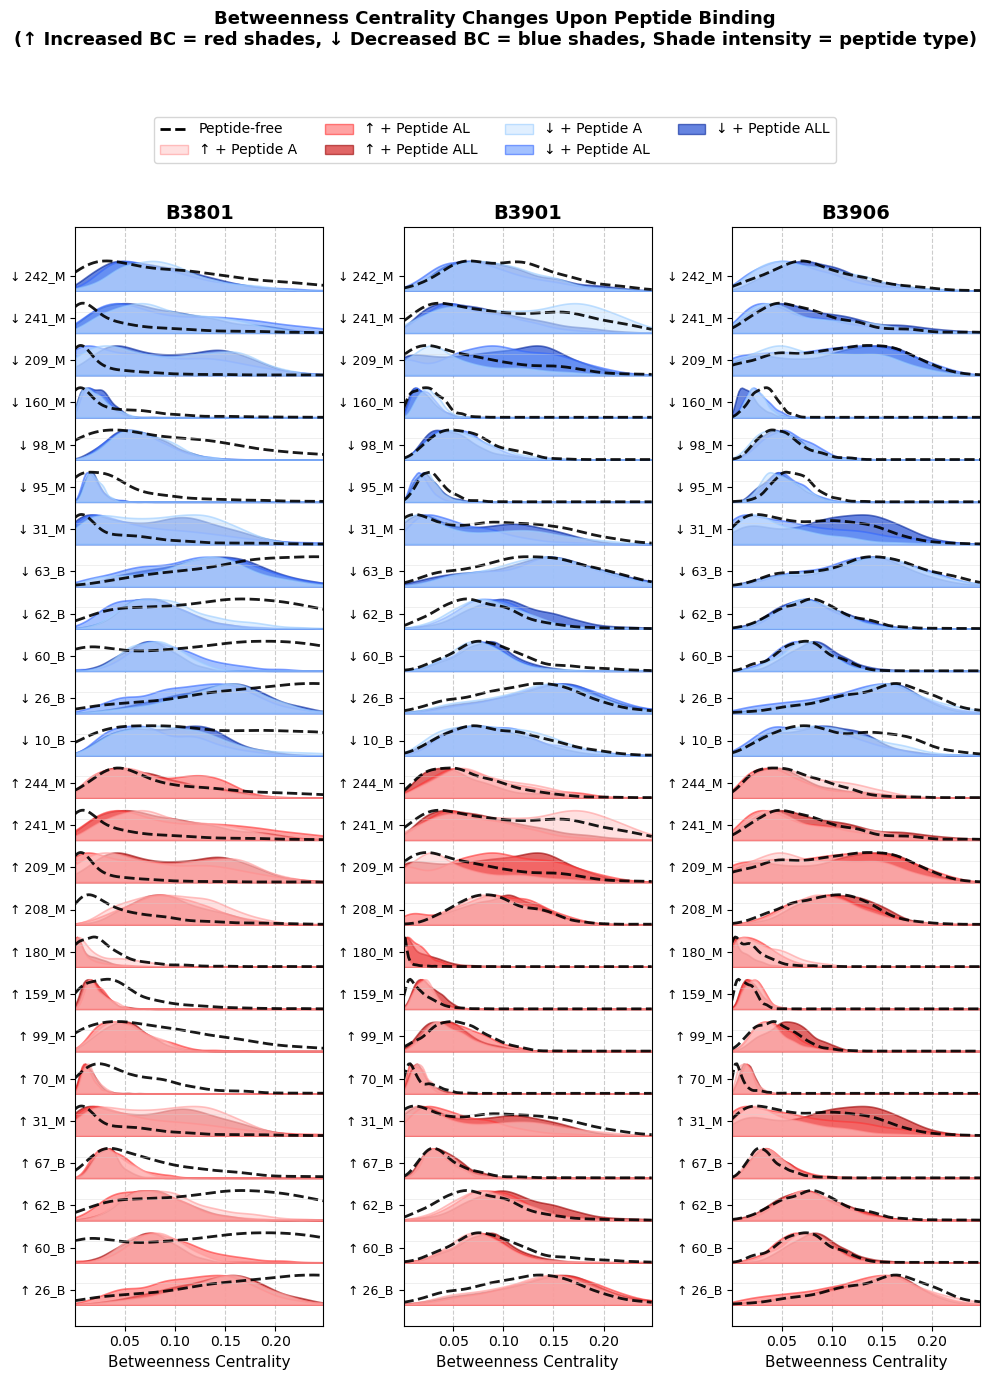

In [17]:
# Generate consolidated ridge plot for all 9 allele-peptide combinations
fig = plot_bc_ridgeplot_grid(
    df_bc_sig_aff_resids,
    df_bc_equil_cons_resids,
    n_residues=3  # 3 top + 3 bottom = 6 per combination
)
plt.show()

# Optionally save to file
# fig.savefig('bc_ridgeplot_grid.png', dpi=300, bbox_inches='tight')

### Identify top residues with increased/decreased centrality upon peptide binding

<Axes: xlabel='Residue_id', ylabel='BC'>

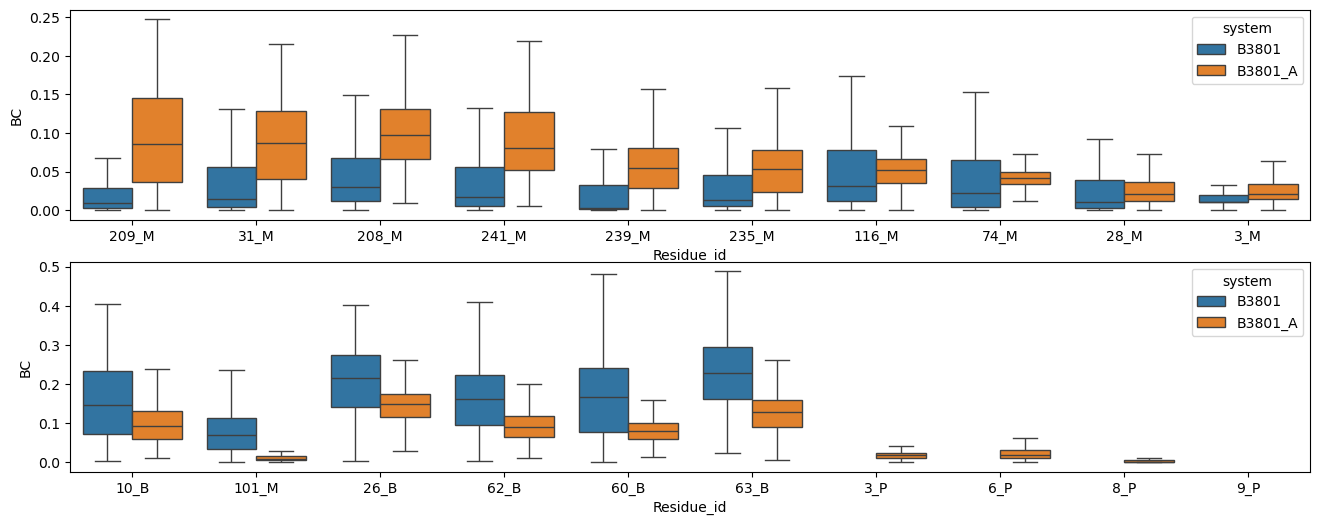

In [6]:
df_bc_sig_aff_resids.sort_values(by='diff_bc_B3801_A',ascending=False, inplace=True)
top10_bc = df_bc_sig_aff_resids[:10]
bottom10_bc = df_bc_sig_aff_resids[-10:]
(fig,ax) = plt.subplots(nrows=2,ncols=1,figsize=(16,6))
df_2plot1 = df_bc_equil_cons_resids[df_bc_equil_cons_resids['system'].isin(['B3801_A','B3801'])]
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(top10_bc['Residue_id'].values)]
order = top10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[0], order=order,showfliers=False)
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(bottom10_bc['Residue_id'].values)]
order = bottom10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[1], order=order,showfliers=False)

<Axes: xlabel='Residue_id', ylabel='BC'>

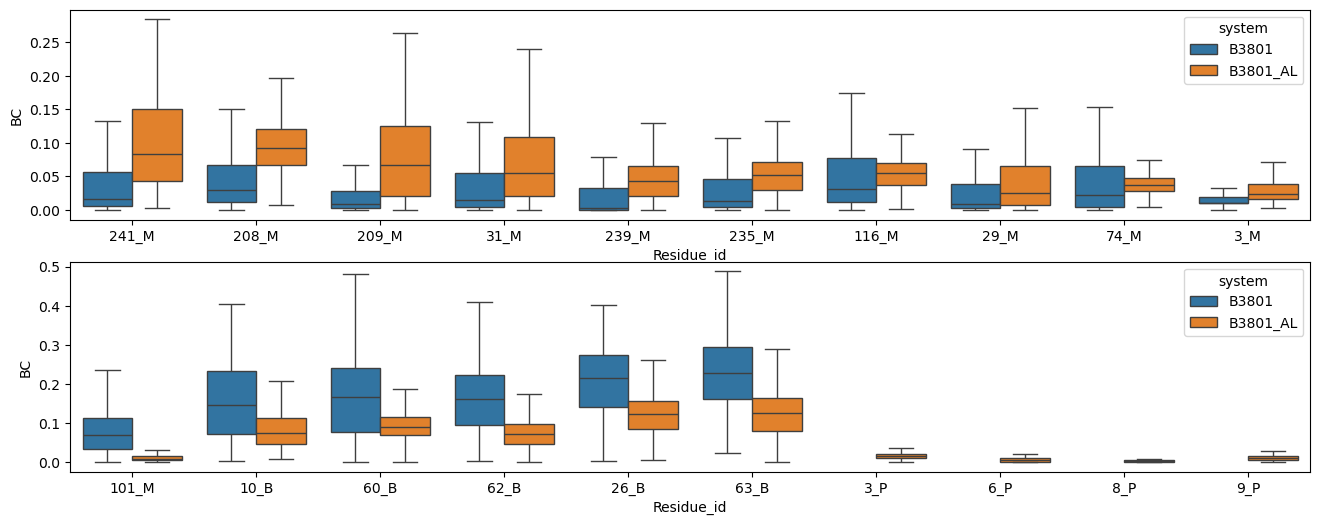

In [7]:
df_bc_sig_aff_resids.sort_values(by='diff_bc_B3801_AL',ascending=False, inplace=True)
top10_bc = df_bc_sig_aff_resids[:10]
bottom10_bc = df_bc_sig_aff_resids[-10:]
(fig,ax) = plt.subplots(nrows=2,ncols=1,figsize=(16,6))
df_2plot1 = df_bc_equil_cons_resids[df_bc_equil_cons_resids['system'].isin(['B3801_AL','B3801'])]
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(top10_bc['Residue_id'].values)]
order = top10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[0], order=order,showfliers=False)
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(bottom10_bc['Residue_id'].values)]
order = bottom10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[1], order=order,showfliers=False)

<Axes: xlabel='Residue_id', ylabel='BC'>

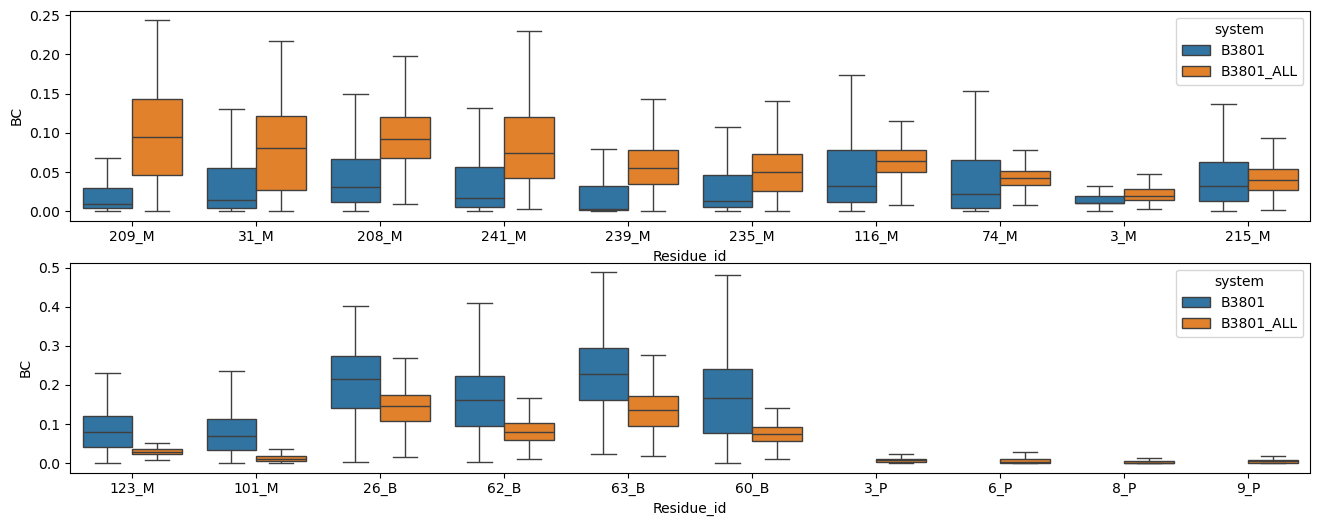

In [8]:
df_bc_sig_aff_resids.sort_values(by='diff_bc_B3801_ALL',ascending=False, inplace=True)
top10_bc = df_bc_sig_aff_resids[:10]
bottom10_bc = df_bc_sig_aff_resids[-10:]
(fig,ax) = plt.subplots(nrows=2,ncols=1,figsize=(16,6))
df_2plot1 = df_bc_equil_cons_resids[df_bc_equil_cons_resids['system'].isin(['B3801_ALL','B3801'])]
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(top10_bc['Residue_id'].values)]
order = top10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[0], order=order,showfliers=False)
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(bottom10_bc['Residue_id'].values)]
order = bottom10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[1], order=order,showfliers=False)

<Axes: xlabel='Residue_id', ylabel='BC'>

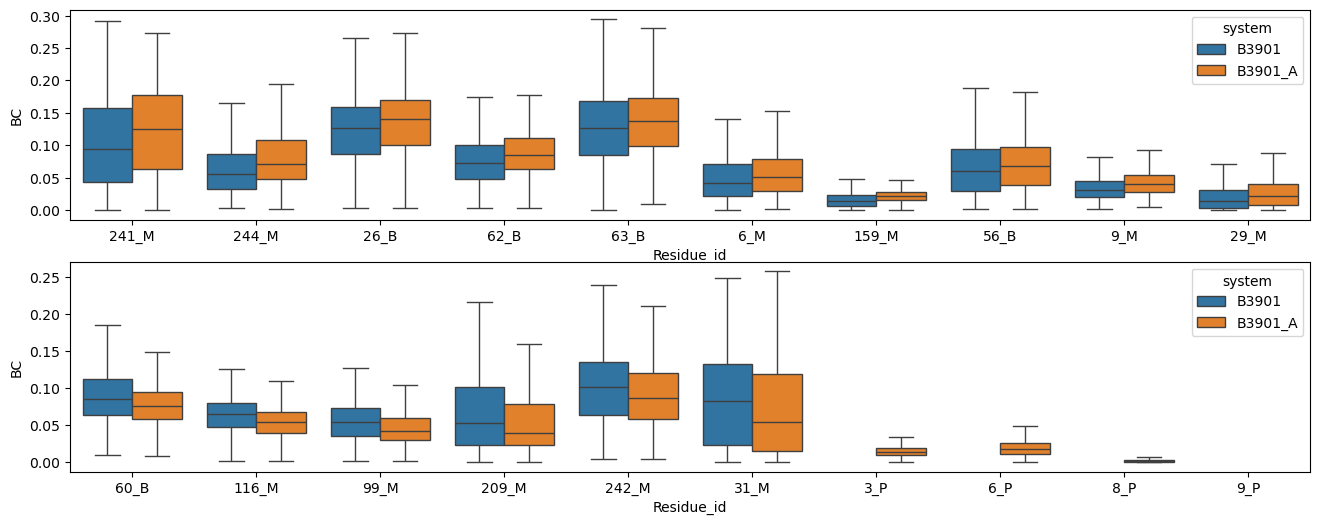

In [10]:
df_bc_sig_aff_resids.sort_values(by='diff_bc_B3901_A',ascending=False, inplace=True)
top10_bc = df_bc_sig_aff_resids[:10]
bottom10_bc = df_bc_sig_aff_resids[-10:]
(fig,ax) = plt.subplots(nrows=2,ncols=1,figsize=(16,6))
df_2plot1 = df_bc_equil_cons_resids[df_bc_equil_cons_resids['system'].isin(['B3901_A','B3901'])]
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(top10_bc['Residue_id'].values)]
order = top10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[0], order=order,showfliers=False)
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(bottom10_bc['Residue_id'].values)]
order = bottom10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[1], order=order,showfliers=False)

<Axes: xlabel='Residue_id', ylabel='BC'>

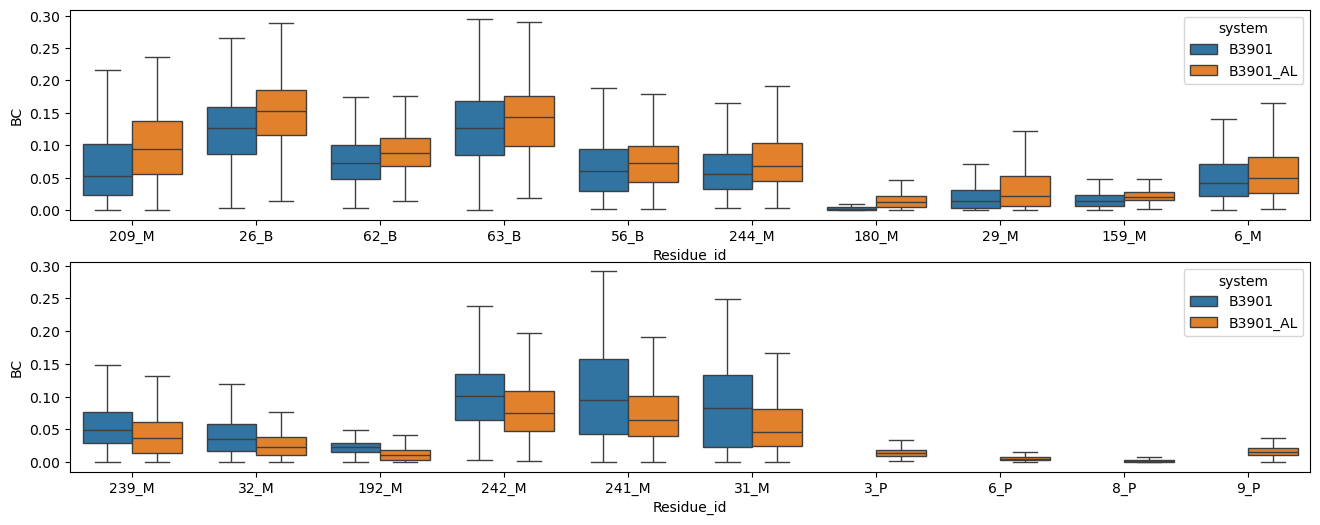

In [11]:
df_bc_sig_aff_resids.sort_values(by='diff_bc_B3901_AL',ascending=False, inplace=True)
top10_bc = df_bc_sig_aff_resids[:10]
bottom10_bc = df_bc_sig_aff_resids[-10:]
(fig,ax) = plt.subplots(nrows=2,ncols=1,figsize=(16,6))
df_2plot1 = df_bc_equil_cons_resids[df_bc_equil_cons_resids['system'].isin(['B3901_AL','B3901'])]
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(top10_bc['Residue_id'].values)]
order = top10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[0], order=order,showfliers=False)
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(bottom10_bc['Residue_id'].values)]
order = bottom10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[1], order=order,showfliers=False)

<Axes: xlabel='Residue_id', ylabel='BC'>

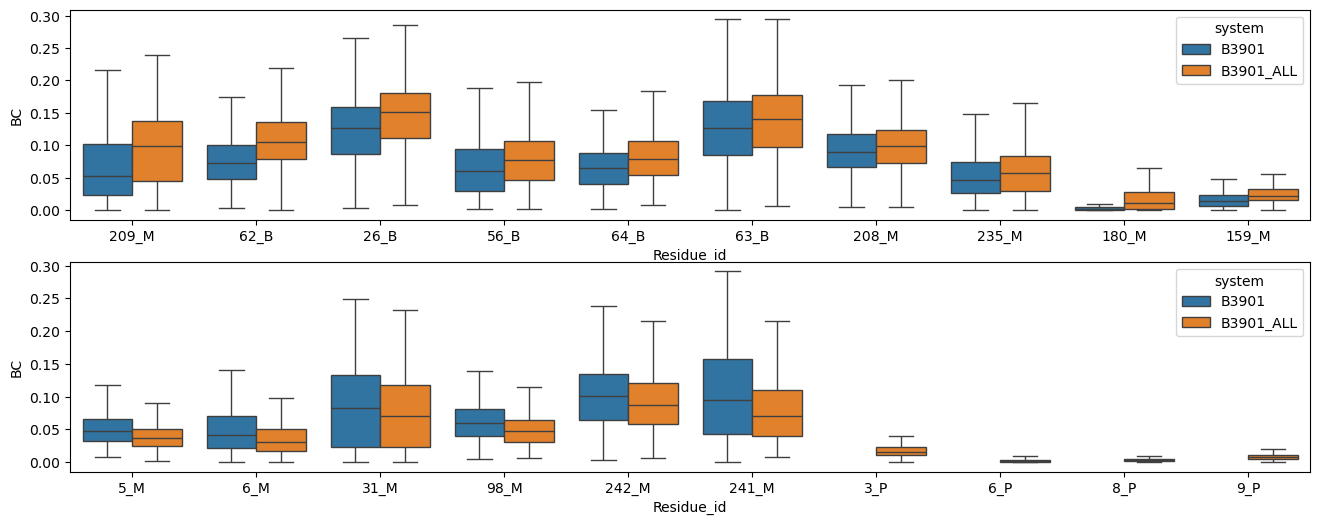

In [12]:
df_bc_sig_aff_resids.sort_values(by='diff_bc_B3901_ALL',ascending=False, inplace=True)
top10_bc = df_bc_sig_aff_resids[:10]
bottom10_bc = df_bc_sig_aff_resids[-10:]
(fig,ax) = plt.subplots(nrows=2,ncols=1,figsize=(16,6))
df_2plot1 = df_bc_equil_cons_resids[df_bc_equil_cons_resids['system'].isin(['B3901_ALL','B3901'])]
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(top10_bc['Residue_id'].values)]
order = top10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[0], order=order,showfliers=False)
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(bottom10_bc['Residue_id'].values)]
order = bottom10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[1], order=order,showfliers=False)

<Axes: xlabel='Residue_id', ylabel='BC'>

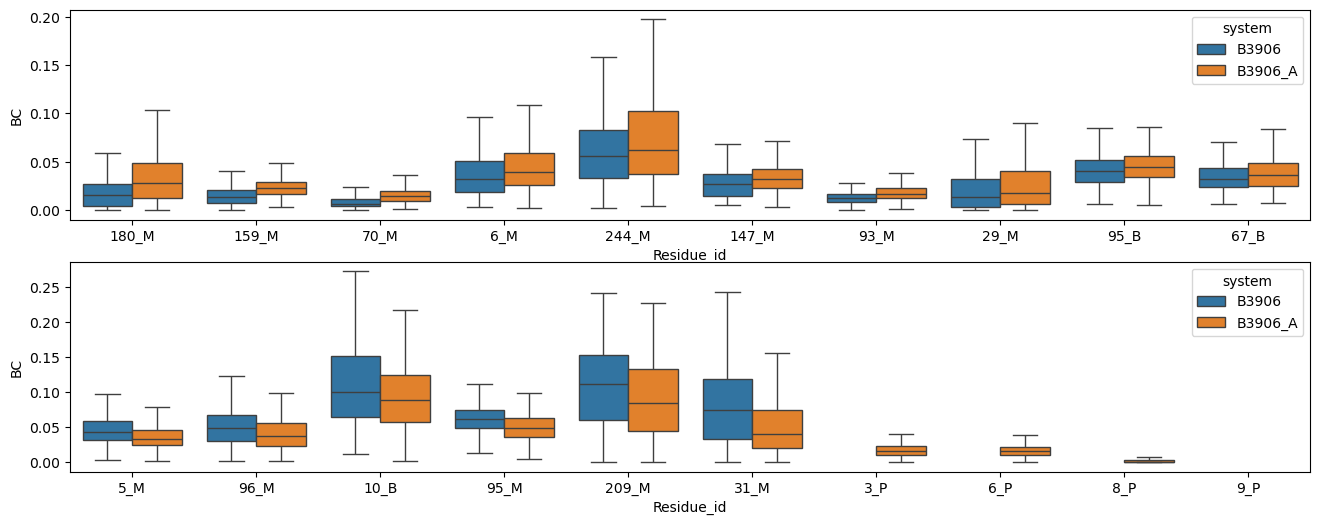

In [13]:
df_bc_sig_aff_resids.sort_values(by='diff_bc_B3906_A',ascending=False, inplace=True)
top10_bc = df_bc_sig_aff_resids[:10]
bottom10_bc = df_bc_sig_aff_resids[-10:]
(fig,ax) = plt.subplots(nrows=2,ncols=1,figsize=(16,6))
df_2plot1 = df_bc_equil_cons_resids[df_bc_equil_cons_resids['system'].isin(['B3906_A','B3906'])]
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(top10_bc['Residue_id'].values)]
order = top10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[0], order=order,showfliers=False)
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(bottom10_bc['Residue_id'].values)]
order = bottom10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[1], order=order,showfliers=False)

<Axes: xlabel='Residue_id', ylabel='BC'>

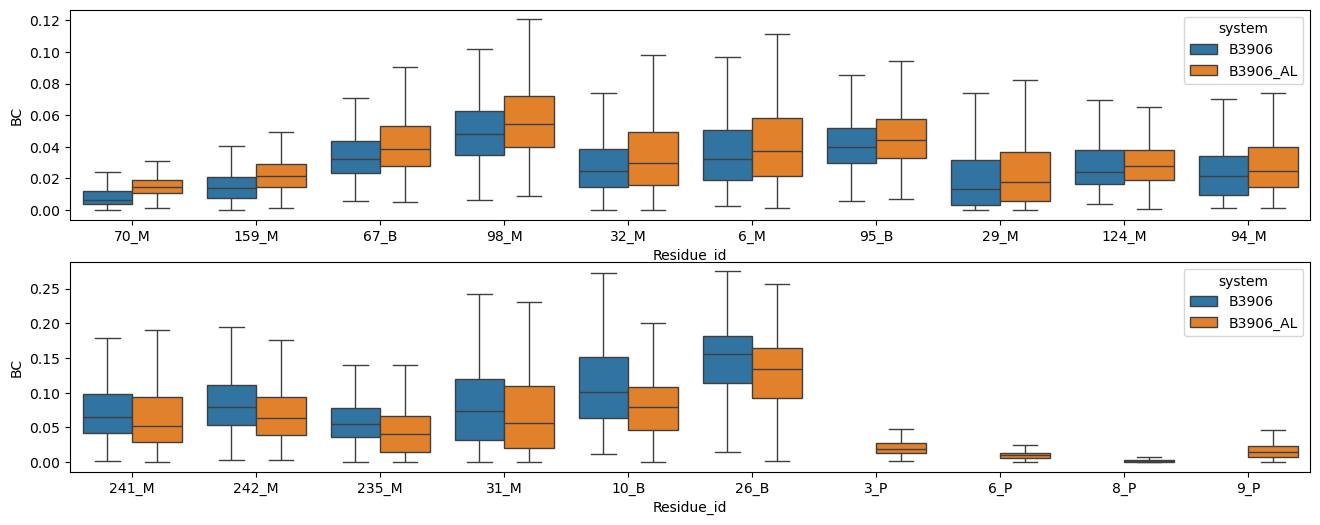

In [14]:
df_bc_sig_aff_resids.sort_values(by='diff_bc_B3906_AL',ascending=False, inplace=True)
top10_bc = df_bc_sig_aff_resids[:10]
bottom10_bc = df_bc_sig_aff_resids[-10:]
(fig,ax) = plt.subplots(nrows=2,ncols=1,figsize=(16,6))
df_2plot1 = df_bc_equil_cons_resids[df_bc_equil_cons_resids['system'].isin(['B3906_AL','B3906'])]
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(top10_bc['Residue_id'].values)]
order = top10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[0], order=order,showfliers=False)
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(bottom10_bc['Residue_id'].values)]
order = bottom10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[1], order=order,showfliers=False)

<Axes: xlabel='Residue_id', ylabel='BC'>

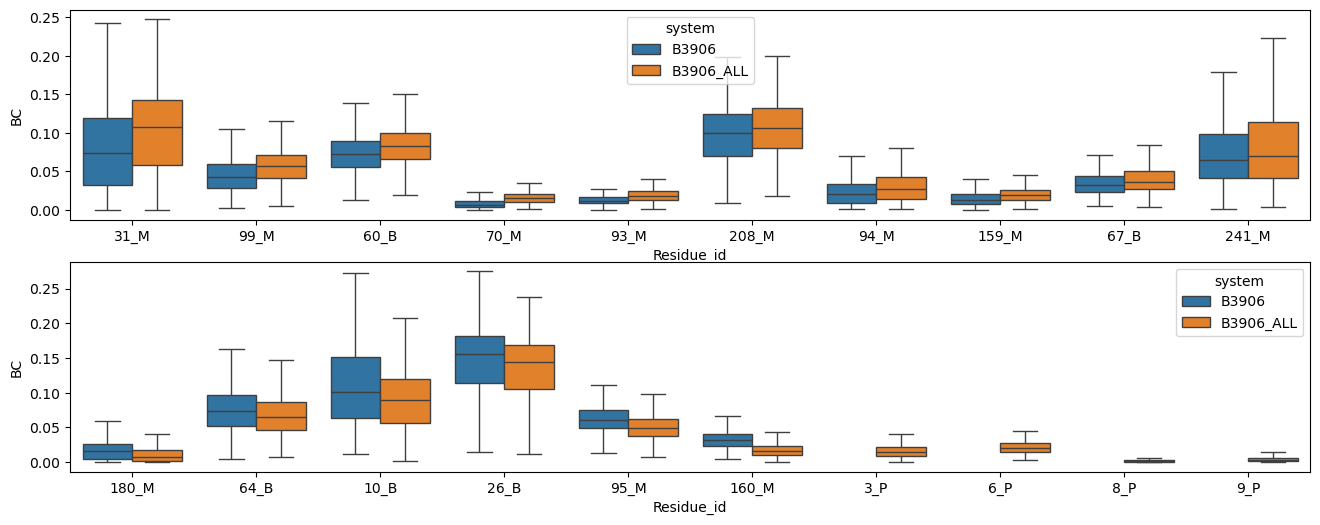

In [9]:
df_bc_sig_aff_resids.sort_values(by='diff_bc_B3906_ALL',ascending=False, inplace=True)
top10_bc = df_bc_sig_aff_resids[:10]
bottom10_bc = df_bc_sig_aff_resids[-10:]
(fig,ax) = plt.subplots(nrows=2,ncols=1,figsize=(16,6))
df_2plot1 = df_bc_equil_cons_resids[df_bc_equil_cons_resids['system'].isin(['B3906_ALL','B3906'])]
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(top10_bc['Residue_id'].values)]
order = top10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[0], order=order,showfliers=False)
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(bottom10_bc['Residue_id'].values)]
order = bottom10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[1], order=order,showfliers=False)

## 2.5 Polymorphic Position Analysis

Analyze interaction energies around polymorphic positions.

In [ ]:
def analyze_polymorphic_residue_interactions(df, residue_id, title_suffix="", figsize_per_subplot=(8, 5)):
    # Determine available frame columns dynamically
    potential_frame_cols = [str(i) for i in range(1000)]
    available_frame_cols = [col for col in potential_frame_cols if col in df.columns]
    
    # Get interactions involving the specified residue
    df_residue = df.query(f"resnum_chain1 == '{residue_id}' or resnum_chain2 == '{residue_id}'")
    
    if len(df_residue) == 0:
        print(f"Warning: No interactions found involving residue {residue_id}")
        return {'filtered_df': df_residue, 'unique_pairs': [], 'pair_counts': {}, 'peptide_summary': {}}
    
    print(f"Found {len(df_residue)} interactions involving residue {residue_id}")
    
    # Get unique peptide values and include peptide-free cases
    unique_peptides = df_residue['peptide'].dropna().unique()
    has_peptide_free = df_residue['peptide'].isna().any()
    
    # Create list of conditions to plot
    conditions = []
    if has_peptide_free:
        conditions.append(('Peptide-free', None))
    for peptide in sorted(unique_peptides):
        conditions.append((f'Peptide: {peptide}', peptide))
    
    print(f"Analyzing {len(conditions)} conditions: {len(unique_peptides)} peptide types + {'peptide-free' if has_peptide_free else 'no peptide-free cases'}")
    
    # Get unique interaction pairs
    unique_pairs = df_residue['resnum_chain12'].unique()
    
    # Initialize summary structures
    pair_counts = {}
    peptide_summary = {}
    
    # Create subplots for each interaction pair
    for resnum_chain12 in unique_pairs:
        df_pair = df_residue[df_residue['resnum_chain12'] == resnum_chain12]
        
        if len(df_pair) == 0:
            continue
        
        # Calculate subplot layout
        n_conditions = len(conditions)
        n_cols = 2
        n_rows = 2
        
        # Create figure with subplots
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize_per_subplot[0] * n_cols, figsize_per_subplot[1] * n_rows))
        if n_conditions == 1:
            axes = [axes]
        elif n_rows == 1:
            axes = axes if isinstance(axes, (list, np.ndarray)) else [axes]
        else:
            axes = axes.flatten()
        
        # Plot each condition
        for idx, (condition_name, peptide_value) in enumerate(conditions):
            ax = axes[idx]
            
            # Filter data for this condition
            if peptide_value is None:  # Peptide-free
                df_condition = df_pair[df_pair['peptide'].isna()]
                condition_key = 'peptide_free'
            else:  # Specific peptide
                df_condition = df_pair[df_pair['peptide'] == peptide_value]
                condition_key = peptide_value
            
            if len(df_condition) == 0:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{condition_name}\n(No data)')
                continue
            
            # Initialize condition in summaries if not exists
            if condition_key not in peptide_summary:
                peptide_summary[condition_key] = {}
            
            alleles_plotted = []
            
            # Plot KDE for each allele in this condition
            for allele in df_condition['allele'].unique():
                df_allele = df_condition[df_condition['allele'] == allele]
                
                if len(df_allele) == 0:
                    continue
                    
                interaction_energies = df_allele[available_frame_cols].values.flatten()
                interaction_energies = interaction_energies[~np.isnan(interaction_energies)]
                
                if len(interaction_energies) == 0:
                    continue
                    
                sns.kdeplot(interaction_energies, label=allele, fill=True, alpha=0.7, ax=ax)
                alleles_plotted.append(allele)
                
                # Count pairs per allele and condition
                pair_key = f"{condition_key}_{allele}"
                if pair_key not in pair_counts:
                    pair_counts[pair_key] = 0
                pair_counts[pair_key] += 1
                
                # Update peptide summary
                if allele not in peptide_summary[condition_key]:
                    peptide_summary[condition_key][allele] = 0
                peptide_summary[condition_key][allele] += 1
            
            # Customize subplot
            if alleles_plotted:
                ax.set_title(f'{condition_name}\n{resnum_chain12}')
                ax.set_xlabel('Interaction Energy (kJ/mol)')
                ax.set_ylabel('Density')
                ax.legend(fontsize='small')
                ax.grid(True, alpha=0.3)
            else:
                ax.text(0.5, 0.5, 'No valid data', ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{condition_name}\n(No valid data)')
        
        # Hide unused subplots
        for idx in range(len(conditions), len(axes)):
            axes[idx].set_visible(False)
        
        # Add overall title and adjust layout
        fig.suptitle(f'Interaction energies for {resnum_chain12} across all conditions{title_suffix}', 
                     fontsize=14, y=0.98)
        plt.tight_layout()
        plt.subplots_adjust(top=0.92)
        plt.show()
    
    # Print comprehensive summary
    print(f"\n=== Summary for residue {residue_id} ===")
    print(f"Total unique interaction pairs: {len(unique_pairs)}")
    print(f"Conditions analyzed: {len(conditions)}")
    
    print(f"\nPairs per condition and allele:")
    for condition_key, allele_counts in peptide_summary.items():
        condition_name = "Peptide-free" if condition_key == 'peptide_free' else f"Peptide: {condition_key}"
        print(f"  {condition_name}: {allele_counts}")
    
    return {
        'filtered_df': df_residue, 
        'unique_pairs': list(unique_pairs), 
        'pair_counts': pair_counts,
        'peptide_summary': peptide_summary,
        'conditions': conditions
    }

In [ ]:
# Analyze residue 74M in peptide-loaded systems
results_74M = analyze_polymorphic_residue_interactions(
    df_cons_pairs, 
    '74M', 
    title_suffix=" (Polymorphic Position)"
)

In [ ]:
# Analyze residue 77M in peptide-loaded systems
results_77M = analyze_polymorphic_residue_interactions(
    df_cons_pairs, 
    '77M', 
    title_suffix=" (Polymorphic Position)"
)

In [ ]:
# Analyze residue 80M in peptide-loaded systems
results_80M = analyze_polymorphic_residue_interactions(
    df_cons_pairs, 
    '80M', 
    title_suffix=" (Polymorphic Position)"
)

In [ ]:
# Analyze residue 81M in peptide-loaded systems
results_81M = analyze_polymorphic_residue_interactions(
    df_cons_pairs, 
    '81M', 
    title_suffix=" (Polymorphic Position)"
)

In [ ]:
# Analyze residue 82M in peptide-loaded systems
results_82M = analyze_polymorphic_residue_interactions(
    df_cons_pairs, 
    '82M', 
    title_suffix=" (Polymorphic Position)"
)

In [ ]:
# Analyze residue 83M in peptide-loaded systems
results_83M = analyze_polymorphic_residue_interactions(
    df_cons_pairs, 
    '83M', 
    title_suffix=" (Polymorphic Position)"
)

In [ ]:
# Analyze residue 95M in peptide-loaded systems
results_95M = analyze_polymorphic_residue_interactions(
    df_cons_pairs, 
    '95M', 
    title_suffix=" (Polymorphic Position)"
)

In [ ]:
# Analyze residue 97M in peptide-loaded systems
results_97M = analyze_polymorphic_residue_interactions(
    df_cons_pairs, 
    '97M', 
    title_suffix=" (Polymorphic Position)"
)